In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import SVG
import requests
import re

In [2]:
r = requests.get(
    'https://tablebuilder.singstat.gov.sg/api/table/tabledata/M830117',
    params={
        'limit': 121*39
    }
)

In [3]:
r.json()['Data']

{'id': 'M830117',
 'title': "Marriages Under The Women's Charter By Age Group Of Grooms And Brides, Annual",
 'footnote': 'Total may include marriages with attribute(s) not reported.',
 'frequency': 'Annual',
 'datasource': 'SINGAPORE DEPARTMENT OF STATISTICS',
 'generatedBy': 'SingStat Table Builder',
 'dataLastUpdated': '06/07/2022',
 'dateGenerated': '06/03/2023',
 'offset': None,
 'limit': '4719',
 'sortBy': None,
 'timeFilter': None,
 'between': None,
 'search': None,
 'row': [{'seriesNo': '1',
   'rowText': 'Total',
   'uoM': 'Number',
   'footnote': '',
   'columns': [{'key': '1983', 'value': '17117'},
    {'key': '1984', 'value': '19973'},
    {'key': '1985', 'value': '18495'},
    {'key': '1986', 'value': '15375'},
    {'key': '1987', 'value': '18635'},
    {'key': '1988', 'value': '19782'},
    {'key': '1989', 'value': '18546'},
    {'key': '1990', 'value': '19191'},
    {'key': '1991', 'value': '19985'},
    {'key': '1992', 'value': '21025'},
    {'key': '1993', 'value': '20

In [4]:
df = pd.DataFrame.from_records(r.json()['Data']['row'])
df.head(5)

,seriesNo,rowText,uoM,footnote,columns
0,1,Total,Number,,"[{'key': '1983', 'value': '17117'}, {'key': '1..."
1,1.1,Grooms Aged Under 20 Years,Number,,"[{'key': '1983', 'value': '96'}, {'key': '1984..."
2,1.2,Grooms Aged 20-24 Years,Number,,"[{'key': '1983', 'value': '4348'}, {'key': '19..."
3,1.3,Grooms Aged 25-29 Years,Number,,"[{'key': '1983', 'value': '8066'}, {'key': '19..."
4,1.4,Grooms Aged 30-34 Years,Number,,"[{'key': '1983', 'value': '3157'}, {'key': '19..."


In [5]:
df = df[['seriesNo', 'rowText', 'columns']]
df[['series1','series2']] = df['seriesNo'].str.split('.', expand=True)
df.head(5)

,seriesNo,rowText,columns,series1,series2
0,1,Total,"[{'key': '1983', 'value': '17117'}, {'key': '1...",1,None
1,1.1,Grooms Aged Under 20 Years,"[{'key': '1983', 'value': '96'}, {'key': '1984...",1,1
2,1.2,Grooms Aged 20-24 Years,"[{'key': '1983', 'value': '4348'}, {'key': '19...",1,2
3,1.3,Grooms Aged 25-29 Years,"[{'key': '1983', 'value': '8066'}, {'key': '19...",1,3
4,1.4,Grooms Aged 30-34 Years,"[{'key': '1983', 'value': '3157'}, {'key': '19...",1,4


In [6]:
df.loc[df['series2'].notnull(),'grooms'] = df.loc[df['series2'].notnull(),'rowText']
df.loc[df['series2'].isnull(),'brides'] = df.loc[df['series2'].isnull(),'rowText']
df['brides'] = df['brides'].fillna(method='ffill')
df['grooms'] = df['grooms'].fillna('Total')
df = df[['brides', 'grooms', 'columns']]
df.head(5)

,brides,grooms,columns
0,Total,Total,"[{'key': '1983', 'value': '17117'}, {'key': '1..."
1,Total,Grooms Aged Under 20 Years,"[{'key': '1983', 'value': '96'}, {'key': '1984..."
2,Total,Grooms Aged 20-24 Years,"[{'key': '1983', 'value': '4348'}, {'key': '19..."
3,Total,Grooms Aged 25-29 Years,"[{'key': '1983', 'value': '8066'}, {'key': '19..."
4,Total,Grooms Aged 30-34 Years,"[{'key': '1983', 'value': '3157'}, {'key': '19..."


In [7]:
df = df.explode('columns').reset_index(drop=True)
df = df.join(other=pd.DataFrame.from_records(df['columns'].dropna().values))
df = df.drop(columns=['columns'])
df = df.rename(columns={'key':'year','value':'marriages'})
df.head(5)

,brides,grooms,year,marriages
0,Total,Total,1983,17117
1,Total,Total,1984,19973
2,Total,Total,1985,18495
3,Total,Total,1986,15375
4,Total,Total,1987,18635


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2069 entries, 0 to 2068
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   brides     2069 non-null   object
 1   grooms     2069 non-null   object
 2   year       2000 non-null   object
 3   marriages  2000 non-null   object
dtypes: object(4)
memory usage: 64.8+ KB


In [9]:
df = df.dropna(how='any')
df['year'] = df['year'].astype(np.int64)
df['marriages'] = df['marriages'].astype(np.int64)
df['brides'] = df['brides'].str.replace(r'brides\s+aged\s+', '', regex=True, flags=re.I)
df['brides'] = df['brides'].str.replace(r'\s+years', '', regex=True, flags=re.I)
df['brides'] = pd.Categorical(df['brides'], categories=['Under 20', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60 & Over', 'Total'], ordered=True)
df['grooms'] = df['grooms'].str.replace(r'grooms\s+aged\s+', '', regex=True, flags=re.I)
df['grooms'] = df['grooms'].str.replace(r'\s+years', '', regex=True, flags=re.I)
df['grooms'] = pd.Categorical(df['grooms'], categories=['Under 20', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60 & Over', 'Total'], ordered=True)
df.head(5)

,brides,grooms,year,marriages
0,Total,Total,1983,17117
1,Total,Total,1984,19973
2,Total,Total,1985,18495
3,Total,Total,1986,15375
4,Total,Total,1987,18635


In [10]:
df = df.set_index(keys=['year','brides','grooms'])
df = df.sort_index()
df = df['marriages'].unstack(level=-1)
df = df.fillna(0).astype(np.int64)
df.head(5)

grooms         Under 20  20-24  25-29  30-34  35-39  40-44  45-49  50-54  \
year brides                                                                
1983 Under 20        65    811    417     48      4      1      0      0   
     20-24           29   3148   4175    820    110     26      7      3   
     25-29            2    351   3196   1571    264     66     18      8   
     30-34            0     30    247    630    304     89     47      0   
     Total           96   4348   8066   3157    825    299    159     90   

grooms         55-59  60 & Over  Total  
year brides                             
1983 Under 20      0          0   1346  
     20-24         1          1   8320  
     25-29         3          2   5481  
     30-34         0          0   1372  
     Total        36         41  17117

<Axes: xlabel='grooms', ylabel='brides'>

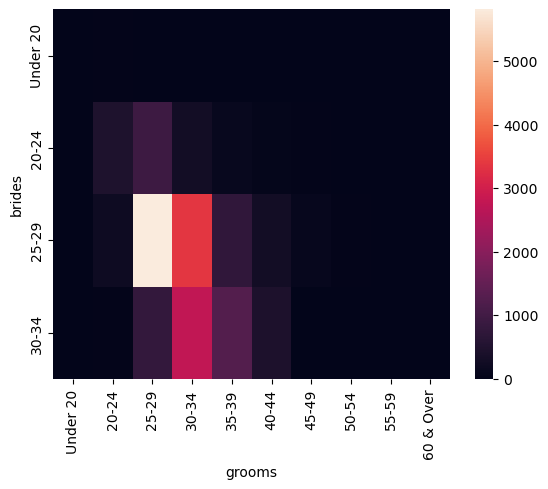

In [11]:
sns.heatmap(df.loc[2017].drop(index='Total').drop(columns='Total'))